## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Folders
raw_path = ROOT / 'data' / 'raw'
helper_path = ROOT / 'data' / 'helper'
clean_output_path = ROOT / 'data' / 'clean'
clean_output_path.mkdir(parents=True, exist_ok=True)

# Jakarta bbox (mainland, exclude Kepulauan Seribu)
jakarta_coor = {
    'lat_min': -6.40, 'lat_max': -6.05,
    'lng_min': 106.65, 'lng_max': 107.00,
}

## Cleaning Function

In [3]:
def in_jakarta(df, lat_col='lat', lng_col='lng'):
    return (
        df[lat_col].between(jakarta_coor['lat_min'], jakarta_coor['lat_max']) &
        df[lng_col].between(jakarta_coor['lng_min'], jakarta_coor['lng_max'])
    )


def dedup_by_coordinat(df, lat_col='lat', lng_col='lng', decimals=5):
    df = df.copy()
    df['_key'] = (df[lat_col].round(decimals).astype(str)+ '_'+ df[lng_col].round(decimals).astype(str))
    df = df.drop_duplicates(subset='_key').drop(columns='_key').reset_index(drop=True)
    return df


def standardize_column_name(df):
    
    if 'latitude' in df.columns:
        df = df.rename(columns={'latitude': 'lat'})

    if 'longitude' in df.columns:
        df = df.rename(columns={'longitude': 'lng'})

    if 'total_reviews' in df.columns:
        df = df.rename(columns={'total_reviews': 'reviews_count'})
    return df


def check_dataframe(df, label):
    print(f"\n[{label}]")
    print(f"\nTotal columns: {df.shape[1]}")
    print(f"Total rows: {df.shape[0]}")
    print(f"\nColumns: {list(df.columns)}")
#     print(f"  Missing values (top 5):")
#     miss = df.isna().sum().sort_values(ascending=False)
#     print(miss[miss > 0].head().to_string())

## Clean Cafes (Google Maps)

In [4]:
cafe_raw = pd.read_csv(raw_path / 'places_cafe.csv')
check_dataframe(cafe_raw, 'Raw Cafe')
cafe_raw.head(5)


[Raw Cafe]

Total columns: 20
Total rows: 2006

Columns: ['place_id', 'name', 'kota', 'kecamatan', 'address', 'latitude', 'longitude', 'primary_type', 'types', 'phone_intl', 'phone_national', 'website', 'google_maps_url', 'rating', 'total_reviews', 'price_category', 'business_status', 'opening_hours', 'list_reviews', 'scraped_at']


,place_id,name,kota,kecamatan,address,latitude,longitude,primary_type,types,phone_intl,phone_national,website,google_maps_url,rating,total_reviews,price_category,business_status,opening_hours,list_reviews,scraped_at
0,ChIJk2S-5gT1aS4R7BfG9zPTqeg,Stroom Coffee,Jakarta Pusat,Gambir,"Jl. M.I. Ridwan Rais No.1, RT.7/RW.1, Gambir, ...",-6.180408,106.832789,Kedai Kopi,"coffee_shop,cafe,point_of_interest,food_store,...",+62 818-0300-1193,0818-0300-1193,https://www.instagram.com/stroom.coffee/,https://maps.google.com/?cid=16765163308017129...,4.5,487.0,NaN,OPERATIONAL,Senin: 08.00–22.00 | Selasa: 08.00–22.00 | Rab...,"[{""author"": ""Titis Satria ig: cerita_kaki"", ""r...",2026-05-28T20:34:36
1,ChIJM-y5dv_3aS4Ru5vfq9j1HK4,Kopi Nako,Jakarta Pusat,Gambir,"Jl. Abdul Muis No.20, RT.11/RW.8, Petojo Sel.,...",-6.172734,106.821282,Kedai Kopi,"coffee_shop,cafe,food_store,food,point_of_inte...",+62 856-1113-191,0856-1113-191,NaN,https://maps.google.com/?cid=12546172972892658...,4.7,5206.0,NaN,OPERATIONAL,Senin: 08.00–02.00 | Selasa: 08.00–02.00 | Rab...,"[{""author"": ""Aditya Bayu"", ""rating_review"": 5,...",2026-05-28T20:34:37
2,ChIJ_YWVAtP1aS4RP0dLZugFvDg,21 Factory Gelato & Coffee,Jakarta Pusat,Gambir,"Jl. Veteran I No.21, RT.4/RW.2, Gambir, Kecama...",-6.170070,106.829746,Kafe,"cafe,point_of_interest,food,establishment",+62 821-2211-3248,0821-2211-3248,http://www.21factory.biz/,https://maps.google.com/?cid=40881490574523287...,4.6,1094.0,PRICE_LEVEL_MODERATE,OPERATIONAL,Senin: 11.00–22.00 | Selasa: 10.00–22.00 | Rab...,"[{""author"": ""Jessica Jane"", ""rating_review"": 5...",2026-05-28T20:34:38
3,ChIJGRmYnyj3aS4RBrjMwAep-HE,9 GRAMS,Jakarta Pusat,Gambir,"Jl. A.M Sangaji No.15A, RT.9/RW.7, Petojo Utar...",-6.167211,106.813952,Kafe,"cafe,point_of_interest,food,establishment",+62 21 6331811,(021) 6331811,http://instagram.com/9grams.id,https://maps.google.com/?cid=82124997712746065...,4.5,651.0,PRICE_LEVEL_MODERATE,OPERATIONAL,Senin: 08.00–22.00 | Selasa: 08.00–22.00 | Rab...,"[{""author"": ""Antonius Bobby S. Wu"", ""rating_re...",2026-05-28T20:34:39
4,ChIJp8FIVeL1aS4RTQt9O2sb8Gg,Loko Cafe Gambir,Jakarta Pusat,Gambir,"RT.5/RW.2, Gambir, Kecamatan Gambir, Jakarta, ...",-6.177873,106.831042,Kafe,"cafe,food,point_of_interest,establishment",+62 811-1754-504,0811-1754-504,NaN,https://maps.google.com/?cid=75615739217285640...,4.4,257.0,NaN,OPERATIONAL,Senin: 07.00–22.00 | Selasa: 07.00–22.00 | Rab...,"[{""author"": ""Ardy Riastomo"", ""rating_review"": ...",2026-05-28T20:34:40


In [5]:
df = cafe_raw.copy()
n0 = len(df)

# standardize column names
df = standardize_column_name(df)

# drop null in latitude and longitude
df = df[df['lat'].notna() & df['lng'].notna()]

# drop null in rating
df = df[df['rating'].notna()]
df['reviews_count'] = df['reviews_count'].fillna(0).astype(int)

# filter data only in jakarta
df = df[in_jakarta(df)]

# filter only cafe/coffee shop
if 'primary_type' or 'type' in df.columns:
    keyword = ['cafe', 'coffee', 'kopi', 'café', 'espresso', 'kedai kopi', 'coffee shop']

    # clean primary type
    mask_primary_type = df['primary_type'].fillna('').str.lower().str.contains('|'.join(keyword))

    # clean types
    mask_types = df['types'].fillna('').str.lower().str.contains('|'.join(keyword))

    # filter based on clean
    df = df[mask_primary_type | mask_types | df['name'].fillna('').str.lower().str.contains('|'.join(keyword))]

# dedupe by coord
df = dedup_by_coordinat(df)

print(f"\nFinal cafes clean: {len(df)} rows (from {n0})")
df.head(3)


Final cafes clean: 1843 rows (from 2006)


,place_id,name,kota,kecamatan,address,lat,lng,primary_type,types,phone_intl,phone_national,website,google_maps_url,rating,reviews_count,price_category,business_status,opening_hours,list_reviews,scraped_at
0,ChIJk2S-5gT1aS4R7BfG9zPTqeg,Stroom Coffee,Jakarta Pusat,Gambir,"Jl. M.I. Ridwan Rais No.1, RT.7/RW.1, Gambir, ...",-6.180408,106.832789,Kedai Kopi,"coffee_shop,cafe,point_of_interest,food_store,...",+62 818-0300-1193,0818-0300-1193,https://www.instagram.com/stroom.coffee/,https://maps.google.com/?cid=16765163308017129...,4.5,487,NaN,OPERATIONAL,Senin: 08.00–22.00 | Selasa: 08.00–22.00 | Rab...,"[{""author"": ""Titis Satria ig: cerita_kaki"", ""r...",2026-05-28T20:34:36
1,ChIJM-y5dv_3aS4Ru5vfq9j1HK4,Kopi Nako,Jakarta Pusat,Gambir,"Jl. Abdul Muis No.20, RT.11/RW.8, Petojo Sel.,...",-6.172734,106.821282,Kedai Kopi,"coffee_shop,cafe,food_store,food,point_of_inte...",+62 856-1113-191,0856-1113-191,NaN,https://maps.google.com/?cid=12546172972892658...,4.7,5206,NaN,OPERATIONAL,Senin: 08.00–02.00 | Selasa: 08.00–02.00 | Rab...,"[{""author"": ""Aditya Bayu"", ""rating_review"": 5,...",2026-05-28T20:34:37
2,ChIJ_YWVAtP1aS4RP0dLZugFvDg,21 Factory Gelato & Coffee,Jakarta Pusat,Gambir,"Jl. Veteran I No.21, RT.4/RW.2, Gambir, Kecama...",-6.170070,106.829746,Kafe,"cafe,point_of_interest,food,establishment",+62 821-2211-3248,0821-2211-3248,http://www.21factory.biz/,https://maps.google.com/?cid=40881490574523287...,4.6,1094,PRICE_LEVEL_MODERATE,OPERATIONAL,Senin: 11.00–22.00 | Selasa: 10.00–22.00 | Rab...,"[{""author"": ""Jessica Jane"", ""rating_review"": 5...",2026-05-28T20:34:38


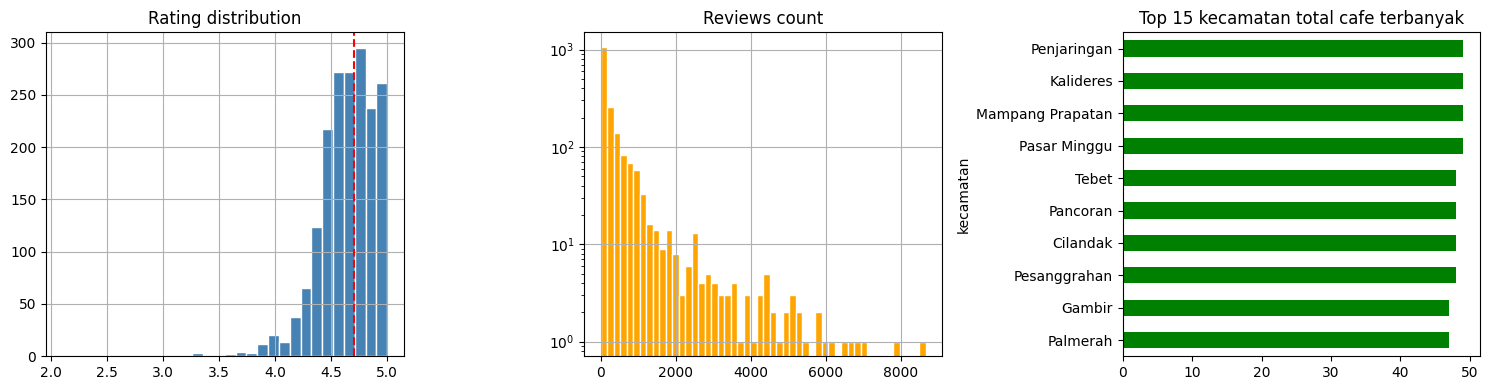

In [6]:
# distribution data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['rating'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating distribution')
axes[0].axvline(df['rating'].median(), color='red', linestyle='--')

df['reviews_count'].hist(bins=50, ax=axes[1], color='orange', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Reviews count')

if 'kecamatan' in df.columns:
    top_kec = df['kecamatan'].value_counts().head(10)
    top_kec.plot.barh(ax=axes[2], color='green')
    axes[2].set_title('Top 15 kecamatan total cafe terbanyak')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [7]:
# Save
out = clean_output_path / 'cafes_clean.csv'
df.to_csv(out, index=False)
print(f"Saved: {out} ({len(df)} rows)")

cafes_clean = df.copy()

Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/cafes_clean.csv (1843 rows)


## Clean Owner Stores

In [8]:
owner_raw = pd.read_csv(helper_path / 'owner_stores.csv')
check_dataframe(owner_raw, 'Raw Owner Store')
owner_raw.head(5)


[Raw Owner Store]

Total columns: 12
Total rows: 18

Columns: ['store_id', 'nama', 'brand', 'alamat', 'kota', 'kecamatan', 'lat', 'lng', 'tipe', 'kapasitas_kursi', 'tanggal_buka', 'omzet_bulanan_juta']


,store_id,nama,brand,alamat,kota,kecamatan,lat,lng,tipe,kapasitas_kursi,tanggal_buka,omzet_bulanan_juta
0,KS-001,Kopi Selapas Senopati,Kopi Selapas,"Jl. Senopati No. 45, Kebayoran Baru",Jakarta Selatan,Kebayoran Baru,-6.2297,106.8195,flagship,48,2021-03-15,185
1,KS-002,Kopi Selapas SCBD,Kopi Selapas,"SCBD Lot 8, Lobby Gedung Pacific Place",Jakarta Selatan,Setiabudi,-6.2240,106.8093,kiosk,12,2022-01-10,142
2,KS-003,Kopi Selapas Tebet,Kopi Selapas,Jl. Tebet Raya No. 88,Jakarta Selatan,Tebet,-6.2298,106.8546,flagship,52,2020-08-22,168
3,KS-004,Kopi Selapas PIM 2,Kopi Selapas,Pondok Indah Mall 2 Ground Floor,Jakarta Selatan,Kebayoran Lama,-6.2663,106.7832,regular,30,2021-11-05,128
4,KS-005,Kopi Selapas Kemang,Kopi Selapas,Jl. Kemang Raya No. 22,Jakarta Selatan,Mampang Prapatan,-6.2603,106.8137,regular,36,2022-06-18,98


In [9]:
df = owner_raw.copy()

# Standardize
df = standardize_column_name(df)

# Coord valid
df = df[df['lat'].notna() & df['lng'].notna()]
df = df[in_jakarta(df)]

print(f"Owner stores clean: {len(df)} (from {n0})")

# Save
out = clean_output_path / 'owner_clean.csv'
df.to_csv(out, index=False)
print(f"Saved: {out}")

owner_clean = df.copy()
df.head()

Owner stores clean: 16 (from 2006)
Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/owner_clean.csv


,store_id,nama,brand,alamat,kota,kecamatan,lat,lng,tipe,kapasitas_kursi,tanggal_buka,omzet_bulanan_juta
0,KS-001,Kopi Selapas Senopati,Kopi Selapas,"Jl. Senopati No. 45, Kebayoran Baru",Jakarta Selatan,Kebayoran Baru,-6.2297,106.8195,flagship,48,2021-03-15,185
1,KS-002,Kopi Selapas SCBD,Kopi Selapas,"SCBD Lot 8, Lobby Gedung Pacific Place",Jakarta Selatan,Setiabudi,-6.2240,106.8093,kiosk,12,2022-01-10,142
2,KS-003,Kopi Selapas Tebet,Kopi Selapas,Jl. Tebet Raya No. 88,Jakarta Selatan,Tebet,-6.2298,106.8546,flagship,52,2020-08-22,168
3,KS-004,Kopi Selapas PIM 2,Kopi Selapas,Pondok Indah Mall 2 Ground Floor,Jakarta Selatan,Kebayoran Lama,-6.2663,106.7832,regular,30,2021-11-05,128
4,KS-005,Kopi Selapas Kemang,Kopi Selapas,Jl. Kemang Raya No. 22,Jakarta Selatan,Mampang Prapatan,-6.2603,106.8137,regular,36,2022-06-18,98


## 3. Clean OSM POI (4 kategori)

In [10]:
def clean_poi(file_path, category):
    df = pd.read_csv(file_path)
    n0 = len(df)
    
    df = standardize_column_name(df)
    
    # filter coordinat and filter only in jakarta
    df = df[df['lat'].notna() & df['lng'].notna()]
    df = df[in_jakarta(df)]
    
    # Dedupe by coordinat
    df = dedup_by_coordinat(df)
    
    # Drop kolom heavy
    drop_cols = ['all_tags']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    df['category'] = category
    
    print(f"{category}: {len(df)} (from {n0})")
    return df


osm_clean = {}
for cat in ['office', 'mall', 'transit', 'school']:
    file_path = raw_path / f'osm_{cat}_jakarta.csv'
    if not file_path.exists():
        # Coba fallback nama lain
        file_path = raw_path / f'{cat}_jakarta.csv'
    
    if not file_path.exists():
        print(f"!{cat} file not found, skip")
        continue
    
    df_clean = clean_poi(file_path, cat)
    osm_clean[cat] = df_clean
    
    # Save
    out = clean_output_path / f'osm_{cat}_clean.csv'
    df_clean.to_csv(out, index=False)
    print(f"Saved: {out}")

office: 3782 (from 3782)
Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/osm_office_clean.csv
mall: 637 (from 637)
Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/osm_mall_clean.csv
transit: 4627 (from 4627)
Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/osm_transit_clean.csv
school: 6387 (from 6387)
Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/osm_school_clean.csv


## Cek Lokasi vs Owner Stores

In [11]:
from src.utils.geo import haversine_vectorized

# Cek apakah ada owner store yang muncul juga di Google scrape (≤100m)
matches = []
for _, owner_row in owner_clean.iterrows():
    d = haversine_vectorized(
        owner_row['lat'], owner_row['lng'],
        cafes_clean['lat'].values, cafes_clean['lng'].values
    )
    nearest_idx = d.argmin()
    nearest_dist = d[nearest_idx]
    
    if nearest_dist < 100:
        matches.append({
            'owner_name': owner_row['nama'],
            'gmaps_name': cafes_clean.iloc[nearest_idx]['name'],
            'distance_m': round(nearest_dist, 1),
        })

if matches:
    print(f"⚠️  Owner store match di Google scrape: {len(matches)}")
    print("  Pertimbangkan exclude dari training data (avoid leakage).")
    pd.DataFrame(matches)
else:
    print("Tidak ada owner store yang overlap dengan Google scrape")

⚠️  Owner store match di Google scrape: 1
  Pertimbangkan exclude dari training data (avoid leakage).


## 5. Visual Verification — Map

In [12]:
import folium

m = folium.Map(location=[-6.22, 106.83], zoom_start=11, tiles='cartodbpositron')

# Cafe sample (max 300 biar gak berat)
for _, r in cafes_clean.sample(min(300, len(cafes_clean))).iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lng']],
        radius=2, color='orange', fill=True, fill_opacity=0.5,
        popup=f"{r['name']}<br>{r['rating']}★ ({r['reviews_count']})",
    ).add_to(m)

# Owner stores (yellow, lebih besar)
for _, r in owner_clean.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lng']],
        radius=8, color='black', fill=True, fill_color='yellow',
        popup=f"<b>{r['nama']}</b><br>{r.get('tipe', '')}",
    ).add_to(m)

# Save & display
out_map = clean_output_path / 'cleaning_verification_map.html'
m.save(out_map)
print(f"Map saved: {out_map}")
m

Map saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean/cleaning_verification_map.html


## 6. Summary

In [13]:
print("=" * 60)
print("CLEAN DATA SUMMARY")
print("=" * 60)
print(f"Output: {clean_output_path}")

summary = {
    'cafes_clean.csv': len(cafes_clean),
    'owner_clean.csv': len(owner_clean),
}
for cat, df in osm_clean.items():
    summary[f'osm_{cat}_clean.csv'] = len(df)

for k, v in summary.items():
    print(f"  {k:30s}: {v:>5,} rows")

CLEAN DATA SUMMARY
Output: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/clean
  cafes_clean.csv               : 1,843 rows
  owner_clean.csv               :    16 rows
  osm_office_clean.csv          : 3,782 rows
  osm_mall_clean.csv            :   637 rows
  osm_transit_clean.csv         : 4,627 rows
  osm_school_clean.csv          : 6,387 rows
